<a href="https://colab.research.google.com/github/vedant-sangrame/Machine-Learning/blob/main/Prac8_ML_ASSIGNMENT1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Vedant Sangrame (CS23163)**

**Lab-8 Assignment-1 To perform Linear Discriminant Analysis (LDA) and Principal Component Analysis (PCA) separately on a dataset, apply Logistic Regression on the transformed features, and compare the performance of LDA-based and PCA-based models.: To applay principle component analysis for dimensionality reduction and visualize the transformed feature space**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
path="/content/drive/MyDrive/ML_dataset/Breast_Cancer_dataset - Breast_Cancer_dataset.csv" # Changed .gsheet to .csv
df=pd.read_csv(path)
df.head(5)

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


In [ ]:
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis'].map({'M': 1, 'B': 0})
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)

In [ ]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [ ]:
lda = LDA(n_components=1)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

In [ ]:
clf_pca = LogisticRegression()
clf_pca.fit(X_train_pca, y_train)

clf_lda = LogisticRegression()
clf_lda.fit(X_train_lda, y_train)

LogisticRegression()

In [ ]:
y_pred_pca = clf_pca.predict(X_test_pca)
y_pred_lda = clf_lda.predict(X_test_lda)

In [ ]:
print("Accuracy with PCA:", accuracy_score(y_test, y_pred_pca))
print("Accuracy with LDA:", accuracy_score(y_test, y_pred_lda))

print("\nClassification Report (PCA):")
print(classification_report(y_test, y_pred_pca))

print("\nClassification Report (LDA):")
print(classification_report(y_test, y_pred_lda))

Accuracy with PCA: 0.9766081871345029
Accuracy with LDA: 0.9590643274853801

Classification Report (PCA):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       108
           1       0.97      0.97      0.97        63

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171


Classification Report (LDA):
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       108
           1       0.94      0.95      0.94        63

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



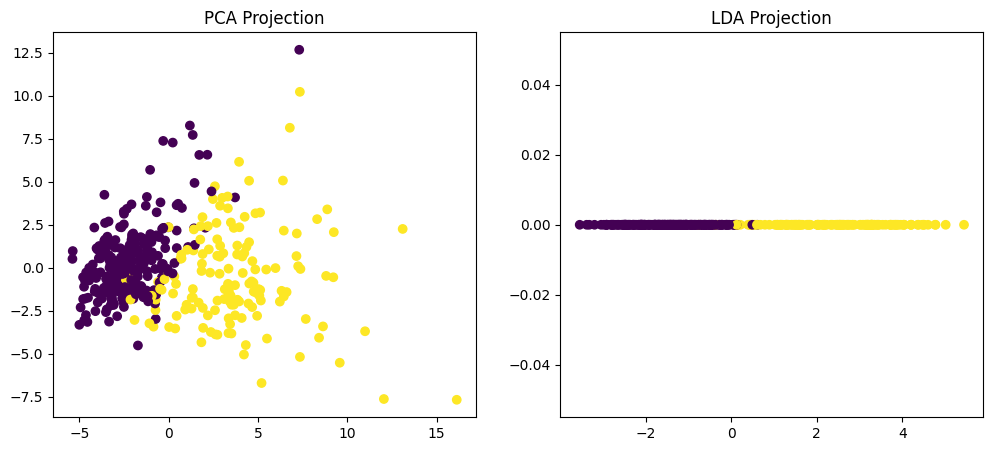

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train)
plt.title("PCA Projection")

plt.subplot(1,2,2)
plt.scatter(X_train_lda[:,0], np.zeros_like(X_train_lda[:,0]), c=y_train) # Fixed line
plt.title("LDA Projection")

plt.show()